# Binary Masks
Here, binary masks are created for every before and after image that focus the region of interest of the samples and remove the backgrounds and possible NaN values in the height files 

In [1]:
from pathlib import Path
import os

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
original_path = Path("../rawdata/processed")
save_path = Path("../rawdata/unet")
before_path = "before"
after_path = "after"
image_path = "centered-image"
height_path = "centered-height"

In [11]:
# Get all image names
sample_ids = [i.replace(".png", "") for i in os.listdir(original_path / before_path / image_path)]
for ident in sample_ids:
    # Read images and heights
    before_image_file = original_path / before_path / image_path / f"{ident}.png"
    before_image = cv.imread(before_image_file, cv.IMREAD_COLOR)

    after_image_file = original_path / after_path / image_path / f"{ident}.png"
    after_image = cv.imread(after_image_file, cv.IMREAD_COLOR)

    before_height_file = original_path / before_path / height_path / f"{ident}.npy"
    before_height = np.load(before_height_file)

    after_height_file = original_path / after_path / height_path / f"{ident}.npy"
    after_height = np.load(after_height_file)

    # Create mask where all channels are zero
    mask = (~np.any(before_image, axis=2)) | (~np.any(after_image, axis=2)) | np.isnan(before_height) | np.isnan(after_height)

    image_mask = np.repeat(mask[:, :, np.newaxis], 3, axis=2)

    before_image[image_mask] = 0
    cv.imwrite(save_path / before_path / "image" / f"{ident}.png", before_image)

    after_image[image_mask] = 0
    cv.imwrite(save_path / after_path / "image" / f"{ident}.png", after_image)

    before_height[mask] = 0.0
    np.save(save_path / before_path / "height" / f"{ident}.npy", before_height)

    after_height[mask] = 0.0
    np.save(save_path / after_path / "height" / f"{ident}.npy", after_height)

    np.save(save_path / "mask" / f"{ident}.npy", mask)

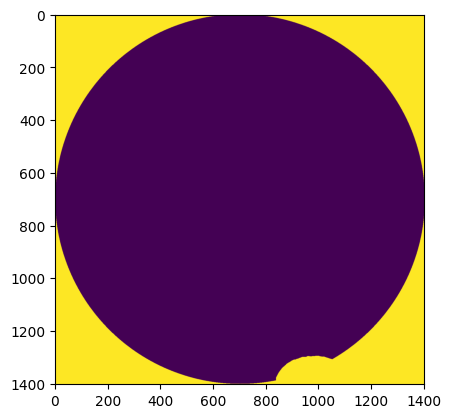

In [18]:
plt.imshow(np.load(save_path / "mask/3-8-3-3.npy"))

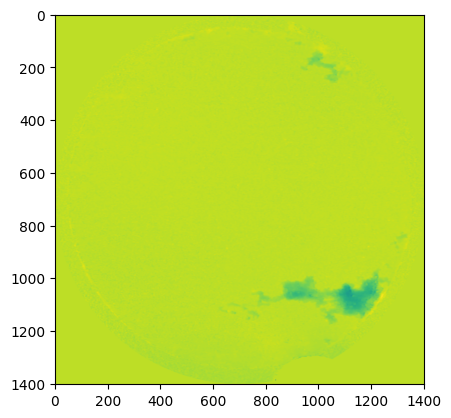

In [19]:
plt.imshow(np.load(save_path / "before/height/3-8-3-3.npy"))

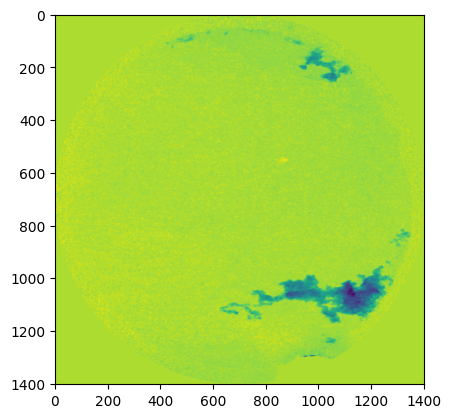

In [20]:
plt.imshow(np.load(save_path / "after/height/3-8-3-3.npy"))

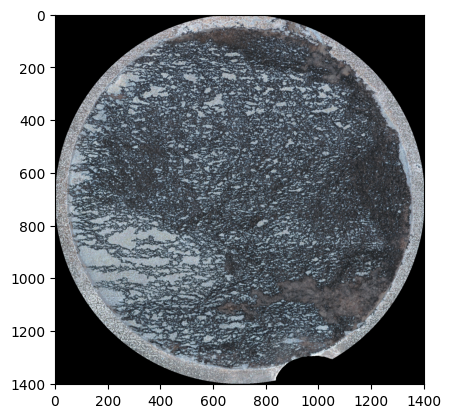

In [23]:
plt.imshow(cv.imread(save_path / "before/image/3-8-3-3.png", cv.IMREAD_COLOR))


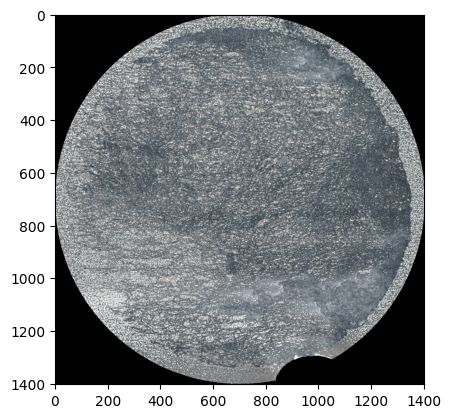

In [24]:
plt.imshow(cv.imread(save_path / "after/image/3-8-3-3.png", cv.IMREAD_COLOR))
